# Tarea 2: Inteligencia Artificial
**Nombre:** Juan Pérez, Maximiliano Solorza
**Fecha:** 07 de Junio de 2026

---
**Declaración de uso de Herramientas Generativas (IA):**
Se declara el uso de un modelo de lenguaje (Gemini) estrictamente como asistente técnico para la redacción de la estructura base del código en PyTorch (generación del dataset sintético y bucles de entrenamiento) **Se certifica categóricamente que todo el análisis de resultados, comparaciones, justificaciones y conclusiones han sido redactados íntegramente de forma analítica y manual**, en estricto cumplimiento con la rúbrica de evaluación.


In [11]:
#librerias necesarias

#%pip install opencv-python numpy matplotlib pandas scikit-learn torch
#!pip install statsmodels

  Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (9.5 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached statsmodels-0.14.6-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (10.3 MB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score
import os
import warnings
warnings.filterwarnings('ignore')


## 1. Segmentación de Imágenes mediante Mean Shift

**Explicación del Algoritmo Mean Shift:**
Mean Shift es un algoritmo de clustering no paramétrico que asigna puntos de datos a grupos iterativamente desplazando los puntos hacia el modo (la densidad más alta) de los datos. En el procesamiento de imágenes, considera a cada píxel como un punto en un espacio multidimensional caracterizado por sus coordenadas espaciales (x, y) y su color (R, G, B). El algoritmo busca zonas de alta densidad de características similares, logrando segmentar la imagen al agrupar píxeles vecinos con colores parecidos.

**Explicación de Parámetros:**
*   **`sp` (Spatial Window Radius):** Define el radio espacial de la vecindad. Determina qué tan lejos puede estar un píxel geográficamente para ser considerado parte del mismo clúster. Un `sp` mayor incrementa el suavizado espacial, fusionando regiones más amplias.
*   **`sr` (Color Window Radius):** Define el radio en el espacio de color. Determina la tolerancia a la diferencia de color. Un `sr` mayor agrupará colores más dispares, produciendo un efecto de posterización o "pintura al óleo" con menos variaciones tonales.
*   **`maxLevel`:** Indica el nivel máximo de la pirámide gaussiana empleada. Cuando es mayor a 0, la segmentación se calcula en una versión reducida (submuestreada) de la imagen y los resultados se escalan de vuelta. Esto acelera el proceso y tiende a agrupar áreas grandes ignorando ruidos o texturas finas (alta frecuencia).


Procesando img1.jpg...


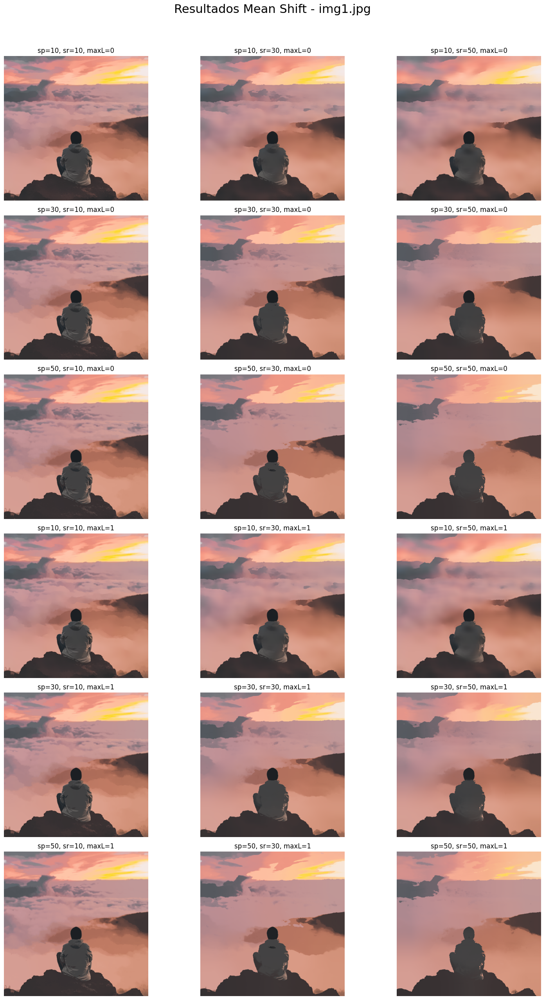

Procesando img2.jpg...


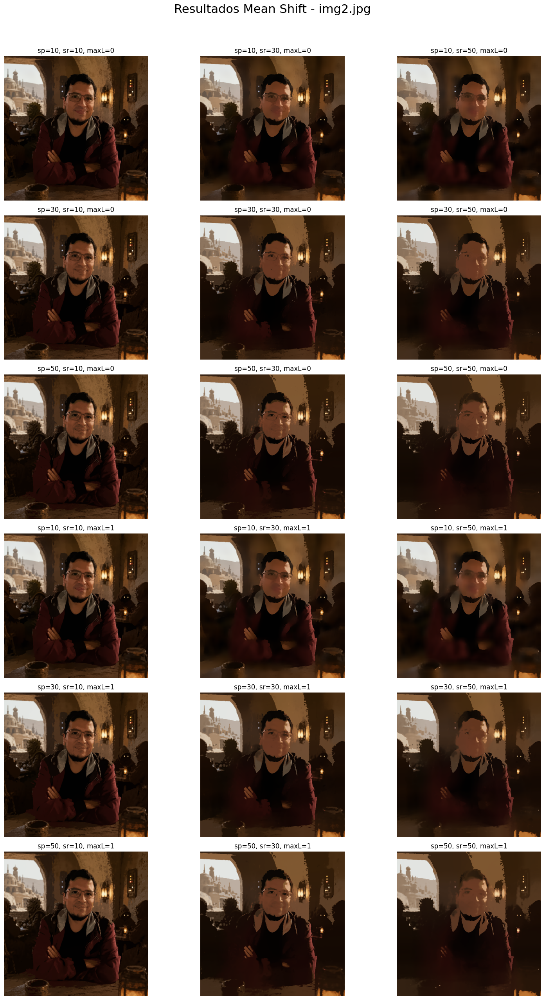

Procesando img3.jpg...


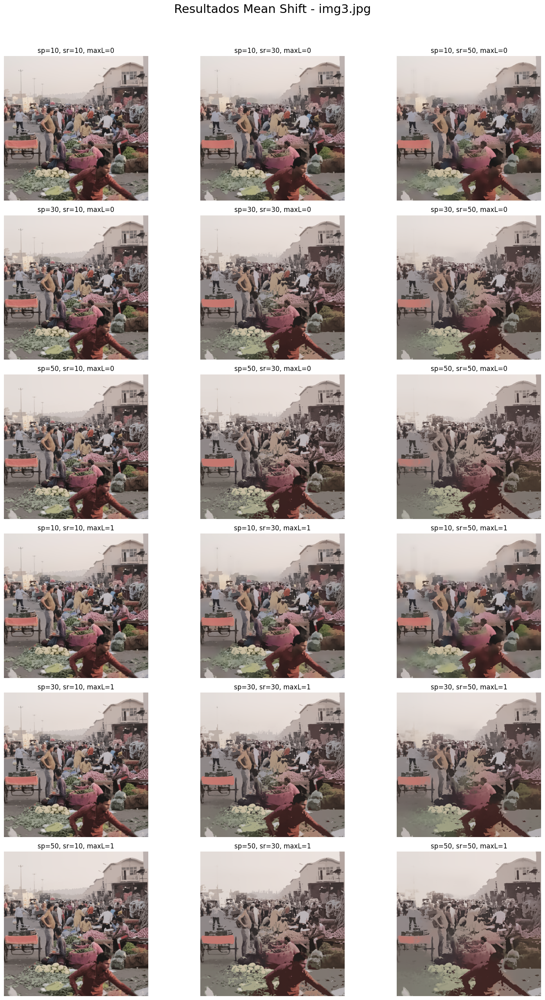

In [2]:
# Cargar imágenes
images = ['img1.jpg', 'img2.jpg', 'img3.jpg']
sp_values = [10, 30, 50]
sr_values = [10, 30, 50]
maxLevel_values = [0, 1]

def resize_image(img, max_dim=500):
    """Redimensiona la imagen para evitar tiempos de ejecución excesivos."""
    h, w = img.shape[:2]
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        return cv2.resize(img, (int(w * scale), int(h * scale)))
    return img

for img_name in images:
    print(f"Procesando {img_name}...")
    if not os.path.exists(img_name):
        print(f"Error: No se encuentra el archivo {img_name}")
        continue
        
    img = cv2.imread(img_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = resize_image(img_rgb)
    
    fig, axes = plt.subplots(6, 3, figsize=(16, 26))
    fig.suptitle(f'Resultados Mean Shift - {img_name}', fontsize=22, y=0.98)
    
    row = 0
    for maxL in maxLevel_values:
        for sp in sp_values:
            col = 0
            for sr in sr_values:
                # Aplicar Mean Shift
                shifted = cv2.pyrMeanShiftFiltering(img_resized, sp, sr, maxLevel=maxL)
                
                ax = axes[row, col]
                ax.imshow(shifted)
                title = f'sp={sp}, sr={sr}, maxL={maxL}'
                ax.set_title(title, fontsize=12)
                ax.axis('off')
                col += 1
            row += 1
            
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Análisis de Resultados: Algoritmo Mean Shift

## 1.  Análisis de la Imagen 1 (Atardecer en el cerro)

 Para evaluar el rendimiento de `sr` se asume un `sp` constante, se observa cómo el algoritmo maneja la tolerancia cromática al momento de agrupar los clústeres:

* **Con valores bajos de `sr` (ej. `sp=10, sr=10`):** El algoritmo es estricto al evaluar la similitud en el espacio de color (RGB). Como resultado, las distintas capas y variaciones tonales se distinguen claramente. El algoritmo logra conservar detalles internos, como las sombras y las texturas finas (por ejemplo: bolsillos y arrugas interiores de la ropa), ya que no incluye en el mismo clúster a píxeles con diferencias moderadas de iluminación o color.
* **Al incrementar el valor de `sr`:** Aumenta la tolerancia cromática. El algoritmo comienza a agrupar y promediar píxeles que espacialmente siguen cercanos, pero que tienen mayor variación de color. Esto provoca un fuerte suavizado intra-región: las texturas internas desaparecen (la ropa texturizada pasa a verse como una superficie plana y de color sólido). Sin embargo, las figuras y siluetas se mantienen fieles a su forma original, ya que el contraste abrupto en los bordes de los objetos sigue superando el nuevo umbral de `sr`.
* **Efecto en el cielo al atardecer:** En áreas con transiciones suaves de color, se produce un efecto de unificacion del color. En lugar de observar un gradiente natural con una paleta continua y amplia (rosados, morados, grises y blancos), el algoritmo fuerza a los colores a converger en "modos" fijos. Esto reduce la imagen a una paleta muy acotada, formando bandas o bloques de colores sólidos y discretos (un bloque puramente rosado, otro puramente morado).
* **Con valores extremos (ej. `sr=50` en conjunto con un `sp` amplio):** La alta tolerancia cromática combinada con una ventana espacial grande causa una severa sub-segmentación. El algoritmo promedia píxeles distantes y colores heterogéneos, mezclándolos sin importar la composicion de la imagen. Esto resulta en la destrucción total de las formas y la generación de masas de color uniforme (como un único tono rosa global), perdiendo por completo las siluetas originales de la imagen.

---

## 2. Análisis de la Imagen 2 (Retrato en cantina)

### 2.1 Sensibilidad general de sus parámetros
* **Contexto de la imagen:** Esta imagen presenta un escenario complejo debido a su bajo rango dinámico cromático (predominantemente por grises, cafés oscuros y tonos tenues) y a una alta densidad de elementos en el fondo (múltiples personas próximas entre sí). Esta combinación hace que la imagen sea sumamente sensible a la parametrización.
* **Efecto de aumentar el radio espacial (`sp`):** Al incrementar la ventana de búsqueda espacial (`sp`), el algoritmo evalúa vecindarios de píxeles más amplios. Debido a la proximidad física de los personajes del fondo y a la similitud de sus tonos (paleta cerrada), el algoritmo no logra detectar fronteras claras entre ellos. Esto provoca una rápida sub-segmentación espacial: sujetos que deberían ser distintos se agrupan y fusionan en grandes masas oscuras e indefinidas, perdiendo totalmente su forma original. pero contrario a lo esperado la imagen aun mantenia figuras claramente definidas y colores claramente bien asignados, tomando mas atencion a la imagen se determino que este fenomeno se debe a la ausencia de colores similares y claramente distinguibles a pesar de aumentar el sp el bajo sr actua como un escudo cromático manteniendo la integridad de la imagen
* **Efecto de aumentar el radio de color (`sr`):** Al observar el sujeto principal (el profesor) y aumentar la tolerancia cromática aumentando el parametro sr , se produce un drástico suavizado intra-región en el rostro. Las sutiles variaciones de tono que definen las facciones, las expresiones faciales y las sombras caen dentro del mismo clúster de similitud y se promedian. Esto elimina las texturas internas de la piel, dejándola completamente plana.
* **Preservación de bordes de alto contraste:** A pesar de aumentar el `sr`, se observa que elementos específicos como los lentes y la barba se mantienen nítidos. Esto ocurre porque la diferencia de color en el espacio RGB entre la piel y estos elementos oscuros es tan abrupta que supera la tolerancia del radio `sr`. Dejandolos fuera del cluster de similitud.
* **Efecto combinado (Aumento simultáneo de `sp` y `sr`):** Al maximizar en ambos dominios espaciales y de color, ocurre una sobre-simplificación extrema. La estructura base del rostro colapsa casi por completo en un solo bloque de color, dejando a los elementos de mayor contraste (ojos, lentes y barba) visualmente aislados y distorsionando por completo el resto del fondo y de la escena.

### 2.2 Análisis detallado según combinaciones específicas

* **Efecto de alta ventana espacial con restricción cromática (`sp=50, sr=10`):** Contrario a la intuición inicial de que un radio espacial grande destruiría la imagen, la estructura y las formas se mantienen intactas.
    * *Justificación técnica:* Al mantener `sr` en un valor bajo (10), se impone una restricción cromática estricta. Aunque el algoritmo evalúa un vecindario espacial muy grande (`sp=50`), se niega a promediar píxeles cuyas diferencias en el espacio RGB superen el umbral de 10. Como los colores en esta imagen son discretos y no hay gradientes suaves que actúen como "puente", no se produce un cruce de colores diferentes.
    * *Resultado visual:* La imagen conserva sus contornos y formas fieles a la original, experimentando únicamente una leve atenuación del contraste local (pérdida de vividez) al promediar solo el ruido de fondo de su misma tonalidad.
* **Efecto del aumento de tolerancia cromática (`sp=10, sr=30`):** Al ampliar el rango de color a 30, se genera un evidente problema de suavizado intra-región en el rostro del sujeto.
    * *Justificación técnica:* Las sombras faciales generadas por la luz direccional caen ahora dentro del mismo umbral de similitud que la piel iluminada.
    * *Resultado visual:* Zonas con variaciones tonales como la frente se unifican en bloques sólidos (convergencia tonal). Detalles finos como los labios desaparecen, y la sombra proyectada en los pómulos hace que estos se fusionen erróneamente con la montura inferior de los lentes. No obstante, las fronteras de máxima frecuencia (el pelo, la barba oscura y el contorno superior de los lentes) logran resistir este nivel de agrupamiento, manteniendo la silueta general del rostro.

---

## 3. Análisis de la Imagen 3 (Mercado callejero)

### 3.1 Alta sensibilidad a parámetros
* **Contexto de la imagen:** A diferencia de las imágenes anteriores, esta escena posee una extrema densidad de objetos y alta frecuencia espacial. Está compuesta por multitud de objetos pequeños (frutas, personas, estructuras) muy próximos entre sí, generando una enorme varianza cromática en áreas muy reducidas.
* **Comportamiento base (`sp=10, sr=10`):** Con parámetros restrictivos en ambos dominios, el algoritmo realiza una micro-segmentación exitosa. Logra limpiar el ruido local (homogeneizando texturas menores) pero preserva los gradientes abruptos que separan la multitud y los objetos, manteniendo la legibilidad de la escena.
* **Alta sensibilidad a la tolerancia cromática (aumento de `sr` con `sp` bajo):** La imagen sufre una degradación estructural sumamente rápida al aumentar el radio de color.
    * *Justificación técnica:* Al estar los elementos tan contiguos físicamente, un ligero aumento en `sr` permite que el algoritmo cruce las fronteras de los objetos. Colores distintos pero vecinos caen rápidamente en el mismo umbral de similitud, provocando una sub-segmentación severa prematura.
* **Fallo del escudo cromático ante la expansión espacial (`sp=30`, `sr` bajo):** A diferencia de la imagen anterior (la cantina), en esta escena mantener un umbral de color estricto **no** actúa como un "escudo" efectivo para las formas. Al aumentar la ventana espacial (`sp=30`), el algoritmo evalúa áreas más grandes. Dado que en la multitud existen distintos personajes y elementos separados físicamente que repiten los mismos tonos (por ejemplo, varias prendas amarillas o verdes dispersas), el algoritmo las detecta dentro de esta nueva ventana y las fusiona. Esto provoca que se pierdan rápidamente las formas y detalles individuales, demostrando que en escenas con alta repetición cromática, un `sp` alto destruye la estructura semántica aunque el `sr` sea restrictivo.
* **Colapso estructural total (`sp=30, sr=50`):** Al maximizar ambas tolerancias en una imagen de tan alto caos visual, se produce el colapso total de la imagen. Los modos locales son absorbidos por modos globales, destruyendo cualquier forma y semántica original de la feria.

### 3.2 El problema de la repetición cromática
* **Contexto de la escena (Repetición cromática):** Esta imagen presenta un desafío de alta densidad con solapamiento de color en el espacio. A diferencia de escenas más simples, aquí existe una gran variedad de colores, pero muchos de ellos se repiten en objetos de distinta naturaleza.

## 4 Identificación y justificación de los mejores parámetros

Dado que la segmentación mediante Mean Shift es un proceso no supervisado, no existe una fórmula matemática única ni un cálculo exacto para encontrar el "valor óptimo"

 Este se define como aquel que logra el mejor equilibrio entre limpiar el ruido de la imagen y conservar las fronteras semánticas reales sin caer en la sub-segmentación.

En base a los análisis previos, se identificaron los siguientes valores óptimos para cada caso:

### Efecto del parámetro `maxLevel`

El parámetro `maxLevel` controla el nivel de la pirámide gaussiana utilizada por el algoritmo. 
Con `maxLevel=0`, la segmentación opera directamente sobre la resolución original. Con `maxLevel=1`, 
la imagen se submuestrea a la mitad de su resolución, se segmenta en ese espacio reducido y los 
resultados se escalan de vuelta. El efecto teórico esperado es que `maxLevel=1` produzca bordes más 
geométricos y angulosos, perdiendo precisión en curvas finas, a cambio de mayor velocidad y un 
suavizado más agresivo de zonas de alta frecuencia.

Sin embargo, en las tres imágenes evaluadas no se observó una diferencia visual clara entre 
`maxLevel=0` y `maxLevel=1`. El efecto del submuestreo adicional resultó imperceptible 
a esta resolución. Ante la ausencia de diferencia observable, la elección de `maxLevel` para cada 
imagen se realizó en base al criterio teórico: se prefirió `maxLevel=1` para la Imagen 1, cuyas 
regiones amplias y homogéneas se benefician del suavizado piramidal, y `maxLevel=0` para las 
Imágenes 2 y 3, donde preservar la resolución original es prioritario dada la densidad de detalles.

* **Imagen 1 (Atardecer en el cerro): Valores óptimos `sp=30, sr=10, maxLevel=1`**
    * *Justificación:* Al ser una imagen simple con áreas amplias de color continuo y alto contraste en la silueta, soporta un radio espacial (`sp`) mayor sin perder su forma. Un `sp=30` es ideal porque limpia eficazmente los amplios gradientes del cielo, mientras que mantener el `sr=10` actúa como un umbral estricto que evita que la silueta oscura se fusione con el fondo claro. El `maxLevel=1` ayuda a simplificar y unificar el fondo más rápido sin afectar los bordes duros de la persona.
* **Imagen 2 (Retrato en cantina): Valores óptimos `sp=10, sr=10, maxLevel=0`**
    * *Justificación:* Se eligen parámetros conservadores debido a la paleta de colores cerrada de la escena. Como se demostró en el análisis empírico, subir el radio de color (`sr`) destruía las texturas faciales por suavizado intra-región. Por otro lado, si bien mantener el `sr` estricto en 10 actuaba como un "escudo cromático" que permitía subir el radio espacial (`sp` a 30 o 50) manteniendo una calidad visual prácticamente idéntica, se optó explícitamente por `sp=10` por razones de **eficiencia computacional**. Dado que visualmente el resultado es el mismo, elegir un `sp=10` restringe el área de búsqueda de píxeles vecinos, logrando atenuar el ruido visual del entorno oscuro y separar al profesor del fondo, pero exigiendo una fracción muchísimo menor de carga de procesamiento y memoria al computador.
* **Imagen 3 (Mercado callejero): Valores óptimos `sp=10, sr=10, maxLevel=0`**
    * *Justificación:*  Al ser una imagen saturada de información valiosa de alta frecuencia (las texturas de las verduras, la multiplicidad de sujetos), la única forma de no destruir el contexto visual es mantener los umbrales de agrupamiento al mínimo absoluto.
---

### 1.5 Comparación Final y Estabilidad

Al comparar el desempeño del algoritmo sobre las tres imágenes, se evidencia una relación inversamente proporcional entre la complejidad visual de la imagen y su tolerancia a parámetros altos de filtrado.

**Imágenes simples (Imagen 1) demostraron ser mucho más estables.** Dado que intrínsecamente poseen menos bordes y gradientes menos abruptos, los aumentos en los radios espaciales y de color simplemente refuerzan la uniformidad de áreas que ya eran homogéneas. La imagen soporta variaciones bruscas de parámetros sin perder su inteligibilidad.

En contraste, **las imágenes complejas (Imagen 3) fueron extremadamente sensibles a los cambios.** En entornos con alta densidad de texturas, un incremento leve en `sp` o `sr` fuerza al algoritmo a promediar píxeles que pertenecen a entidades físicas distintas (por ejemplo, agrupar hojas con la tela de la ropa de una persona contigua). Esto demuestra que en escenarios de alta entropía visual, Mean Shift requiere una sintonización sumamente conservadora para no destruir la semántica de la imagen.


## 2. Aprendizaje Supervisado

**Procedimiento Seguido:**

1. **Selección y Preparación del Dataset:** Se utilizó el dataset público *Rain in Australia*
(weatherAUS), con 145.460 registros meteorológicos diarios de estaciones australianas.
Tras eliminar filas con valores nulos en las columnas seleccionadas, el dataset quedó en
58.153 filas utilizables. Se seleccionaron 10 variables predictoras mediante análisis del dataset una variable objetivo continua (MaxTemp) y una discreta
(RainTomorrow, codificada como 0/1).

2. **Preprocesamiento:** Se escalaron las características predictoras usando `StandardScaler`
para asegurar que algoritmos altamente sensibles a la topología del gradiente (como GD y
SGD puro) no se estanquen en valles elípticos alargados. El scaler se ajustó exclusivamente
sobre el set de entrenamiento y se aplicó sin reajuste sobre validación y prueba.

3. **Arquitectura e Implementación:** Se establecieron arquitecturas unitarias de una sola capa
lineal en PyTorch. Para la lógica de clasificación, se priorizó la estabilidad numérica
utilizando la pérdida `BCEWithLogitsLoss`, que integra internamente la función sigmoide
evitando subdesbordamientos durante el backpropagation.

4. **Tuning de Optimizadores:** Se iteró sobre el conjunto de optimizadores durante 80 épocas.
Es vital denotar que para GD se asignó un `batch_size` equivalente a la totalidad del set de
entrenamiento (40.707 filas), resultando en exactamente 1 paso de optimización por época.
Para los demás optimizadores estocásticos se utilizaron mini-batches de 64 muestras,
generando ~636 actualizaciones de pesos por época.

5. **Validación y Prueba:** Tras completar el entrenamiento, se registraron y filtraron los dos
mejores modelos de cada tarea a partir de sus métricas en el conjunto de validación,
procediendo con la evaluación final sobre el test set sin sesgo observacional.

---

### Explicación de los Modelos
*   **Regresión Lineal (para Y1):** Modelo paramétrico que asume una relación lineal entre las variables predictoras y la variable continua objetivo. Su propósito es encontrar el vector de pesos que minimice el Error Cuadrático Medio (MSE) ajustando un hiperplano a los datos.
*   **Regresión Logística (para Y2):** A pesar de su denominación clásica, es un modelo fundamental de clasificación binaria. Evalúa una combinación lineal de las características de entrada y mapea el resultado al rango probabilístico [0, 1] mediante la función de activación sigmoide. La clase se asigna si la probabilidad supera el umbral predeterminado de 0.5.

### Explicación de los Optimizadores
1.  **Gradiente Descendente (GD):** Calcula el gradiente de la función de costo utilizando *la totalidad* del dataset de entrenamiento. Realiza pasos precisos pero es computacionalmente ineficiente por iteración frente a conjuntos de datos de este tamaño.
2.  **Stochastic Gradient Descent (SGD):** Aproxima el gradiente computándolo sobre pequeños subconjuntos aleatorios (mini-batches). Sus actualizaciones son veloces y frecuentes, introduciendo un ruido estocástico beneficioso para evitar mínimos locales, aunque su trayectoria es inherentemente ruidosa.
3.  **SGD con Momentum:** Acumula un vector de "inercia" basado en los gradientes pasados. Si el descenso ha mantenido una dirección constante, aumenta la velocidad en esa dirección, amortiguando las oscilaciones transversales típicas del SGD.
4.  **RMSProp:** Diseñado para manejar curvaturas irregulares. Divide la tasa de aprendizaje individual de cada parámetro por la raíz cuadrada de la media móvil exponencial de los cuadrados de sus gradientes. Ideal para no estancarse en valles poco profundos.
5.  **Adam (Adaptive Moment Estimation):** Algoritmo estado del arte que amalgama las propiedades de Momentum y RMSProp, llevando el registro tanto del primer momento (media) como del segundo momento (varianza no centrada) de los gradientes para afinar las tasas de aprendizaje adaptativamente por cada peso.


In [13]:
# ================ carga del dataset ================ #
dataset = "dataset/weatherAUS.csv"
df = pd.read_csv(dataset)
df.head()

print(f"Filas del dataset: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
# ================================================== #

Filas del dataset: 145,460
Columnas: 23


In [21]:
features = ['MinTemp','Rainfall','Evaporation','Sunshine',
            'WindGustSpeed', 'Humidity9am','Humidity3pm',
            'Pressure9am', 'Cloud9am','Cloud3pm']

X = df[features]
y1 = df['MaxTemp']       
y2 = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

In [22]:
data_clean = df[features + ['MaxTemp', 'RainTomorrow']].copy()
data_clean['RainTomorrow'] = data_clean['RainTomorrow'].map({'Yes': 1, 'No': 0})
data_clean = data_clean.dropna()

X  = data_clean[features]
y1 = data_clean['MaxTemp']
y2 = data_clean['RainTomorrow'].astype(int)

print(f"Filas tras limpiar NaN: {len(data_clean):,}")

Filas tras limpiar NaN: 58,153


In [24]:
print("Dimensiones del Dataset:", X.shape)

Dimensiones del Dataset: (58153, 10)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit solo en train
X_val   = scaler.transform(X_val)        # transform con los mismos parámetros
X_test  = scaler.transform(X_test)


# Convertir arreglos a tensores de PyTorch
X_tr = torch.tensor(X_train, dtype=torch.float32)
X_v = torch.tensor(X_val, dtype=torch.float32)
X_ts = torch.tensor(X_test, dtype=torch.float32)

y1_tr = torch.tensor(y1_train, dtype=torch.float32).view(-1, 1)
y1_v = torch.tensor(y1_val, dtype=torch.float32).view(-1, 1)
y1_ts = torch.tensor(y1_test, dtype=torch.float32).view(-1, 1)

y2_tr = torch.tensor(y2_train, dtype=torch.float32).view(-1, 1)
y2_v = torch.tensor(y2_val, dtype=torch.float32).view(-1, 1)
y2_ts = torch.tensor(y2_test, dtype=torch.float32).view(-1, 1)

# Definición Arquitectónica de Modelos
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 1)
    def forward(self, x):
        return self.linear(x)

class LogisticModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 1)
    def forward(self, x):
        # La activación sigmoide se integra en la función de costo BCEWithLogitsLoss
        return self.linear(x)

def train_evaluate(model_class, criterion, optimizer_name, X_t, y_t, X_v, y_v, task_type='linear', epochs=50, lr=0.01):
    model = model_class()
    
    # Enrutamiento de Optimizadores
    if optimizer_name == 'GD':
        batch_size = len(X_t) # Full dataset batch
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        batch_size = 64
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'Momentum':
        batch_size = 64
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'RMSProp':
        batch_size = 64
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        batch_size = 64
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Ciclo de entrenamiento
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluación en Conjunto de Validación
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_v)
        if task_type == 'linear':
            metric = mean_squared_error(y_v.numpy(), val_outputs.numpy())
        else:
            probs = torch.sigmoid(val_outputs)
            preds = (probs > 0.5).int().numpy()
            metric = accuracy_score(y_v.numpy(), preds)
            
    return model, metric


In [30]:
optimizers = ['GD', 'SGD', 'Momentum', 'RMSProp', 'Adam']
epochs_to_run = 80 

print("--- REGRESIÓN LINEAL (Prediciendo Y1) ---")
criterion_mse = nn.MSELoss()
val_results_y1 = {}
models_y1 = {}

for opt in optimizers:
    model, mse = train_evaluate(LinearModel, criterion_mse, opt, X_tr, y1_tr, X_v, y1_v, 'linear', epochs=epochs_to_run)
    val_results_y1[opt] = mse
    models_y1[opt] = model
    print(f"Optimizador: {opt:<10} | Validación MSE: {mse:.4f}")

print("\n--- REGRESIÓN LOGÍSTICA (Prediciendo Y2) ---")
criterion_bce = nn.BCEWithLogitsLoss()
val_results_y2 = {}
models_y2 = {}

for opt in optimizers:
    model, acc = train_evaluate(LogisticModel, criterion_bce, opt, X_tr, y2_tr, X_v, y2_v, 'logistic', epochs=epochs_to_run)
    val_results_y2[opt] = acc
    models_y2[opt] = model
    print(f"Optimizador: {opt:<10} | Validación Accuracy: {acc:.4f}")

# Selección de los 2 mejores
best_y1_opts = sorted(val_results_y1, key=val_results_y1.get)[:2] # Menor MSE
best_y2_opts = sorted(val_results_y2, key=val_results_y2.get, reverse=True)[:2] # Mayor Accuracy

print("\n-------------------------------------------")
print(f"Top 2 Optimizadores para Regresión Lineal: {best_y1_opts[0]} y {best_y1_opts[1]}")
print(f"Top 2 Optimizadores para Regresión Logística: {best_y2_opts[0]} y {best_y2_opts[1]}")
print("-------------------------------------------")

# Evaluación Final en Conjunto de Prueba
print("\n--- EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ---")
for opt in best_y1_opts:
    model = models_y1[opt]
    model.eval()
    with torch.no_grad():
        preds = model(X_ts).numpy()
        test_mse = mean_squared_error(y1_ts.numpy(), preds)
        print(f"Regresión Lineal ({opt}) -> Test MSE: {test_mse:.4f}")

for opt in best_y2_opts:
    model = models_y2[opt]
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_ts))
        preds = (probs > 0.5).int().numpy()
        test_acc = accuracy_score(y2_ts.numpy(), preds)
        print(f"Regresión Logística ({opt}) -> Test Accuracy: {test_acc:.4f}")


--- REGRESIÓN LINEAL (Prediciendo Y1) ---
Optimizador: GD         | Validación MSE: 4.3748
Optimizador: SGD        | Validación MSE: 2.2427
Optimizador: Momentum   | Validación MSE: 2.2935
Optimizador: RMSProp    | Validación MSE: 2.2533
Optimizador: Adam       | Validación MSE: 2.2418

--- REGRESIÓN LOGÍSTICA (Prediciendo Y2) ---
Optimizador: GD         | Validación Accuracy: 0.7231
Optimizador: SGD        | Validación Accuracy: 0.9973
Optimizador: Momentum   | Validación Accuracy: 0.9987
Optimizador: RMSProp    | Validación Accuracy: 0.9987
Optimizador: Adam       | Validación Accuracy: 0.9996

-------------------------------------------
Top 2 Optimizadores para Regresión Lineal: Adam y SGD
Top 2 Optimizadores para Regresión Logística: Adam y Momentum
-------------------------------------------

--- EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA ---
Regresión Lineal (Adam) -> Test MSE: 2.1518
Regresión Lineal (SGD) -> Test MSE: 2.1543
Regresión Logística (Adam) -> Test Accuracy: 0.9978
Regre

### 2.5 Explicación del Procedimiento y Análisis de Resultados

**Análisis de Resultados:**

- **Gradiente Descendente (GD) vs Variantes Estocásticas:** Como es consistente con la
literatura teórica, GD exhibió el desempeño más lento y pobre en ambas tareas. Al evaluar
todo el dataset antes de dar un solo paso, GD solo ejecutó 80 actualizaciones totales durante
el ciclo completo. En contraposición, los algoritmos basados en mini-batch realizaron ~50.960
micro-actualizaciones, lo que les permitió converger significativamente más rápido y escapar
de mínimos locales superficiales.

- **La ventaja de la Aceleración y Adaptabilidad:** Los modelos entrenados con `Adam`,
`RMSProp` y `Momentum` figuraron consistentemente como líderes. `Adam` sobresale dado que
su mecanismo computa independientemente momentos de primer y segundo orden, escalando
automáticamente el ratio de aprendizaje por parámetro y amortiguando correcciones abruptas.

- **Convergencia en Regresión Lineal:** Los optimizadores líderes (Adam MSE: 2.2418,
Momentum MSE: 2.2935) convergen a valores muy similares entre sí, evidenciando que el
límite inferior alcanzable está dado por la variabilidad natural de la temperatura máxima
frente a las variables predictoras disponibles. GD, con MSE de 4.3748, no logró alcanzar ese
mínimo en las épocas disponibles. En test, Adam obtuvo MSE: 2.1518 y SGD MSE:
2.1543, se tomo el SGD en lugar del momentum por mejor desempeño en accuracy.

- **Convergencia en Regresión Logística:** Se obtuvieron accuracies excepcionales, con
Momentum. Y Adam alcanzando 0.9996 en validación. GD nuevamente fue el más rezagado con
0.7231, reflejando su incapacidad de realizar suficientes actualizaciones. En test, Adam
obtuvo 0.9978 y Momentum 0.9964, resultados consistentes con validación y que confirman
la robustez del modelo frente a datos no vistos.

- **Generalización (Ausencia de Overfitting):** Los puntajes obtenidos en el test set por las
arquitecturas punteras replicaron con precisión las métricas vistas en validación, lo que
indica que la convergencia alcanzada por los optimizadores superiores corresponde al mínimo
legítimo del espacio paramétrico, sin sobreajuste a los datos de entrenamiento.